In [2]:
# importing the basic libaries we need 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.svm import SVR

diab =  load_diabetes()

print(diab.keys())
print()
print(type(diab))
print()
print(diab.data.shape)
print()
print(diab.target.shape)
print()
print(diab.feature_names)
print()
print(diab.DESCR)

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])

<class 'sklearn.utils._bunch.Bunch'>

(442, 10)

(442,)

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoprotei

In [4]:
df = pd.DataFrame(diab.data, columns=diab.feature_names)
df['target']= diab.target
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
None
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 

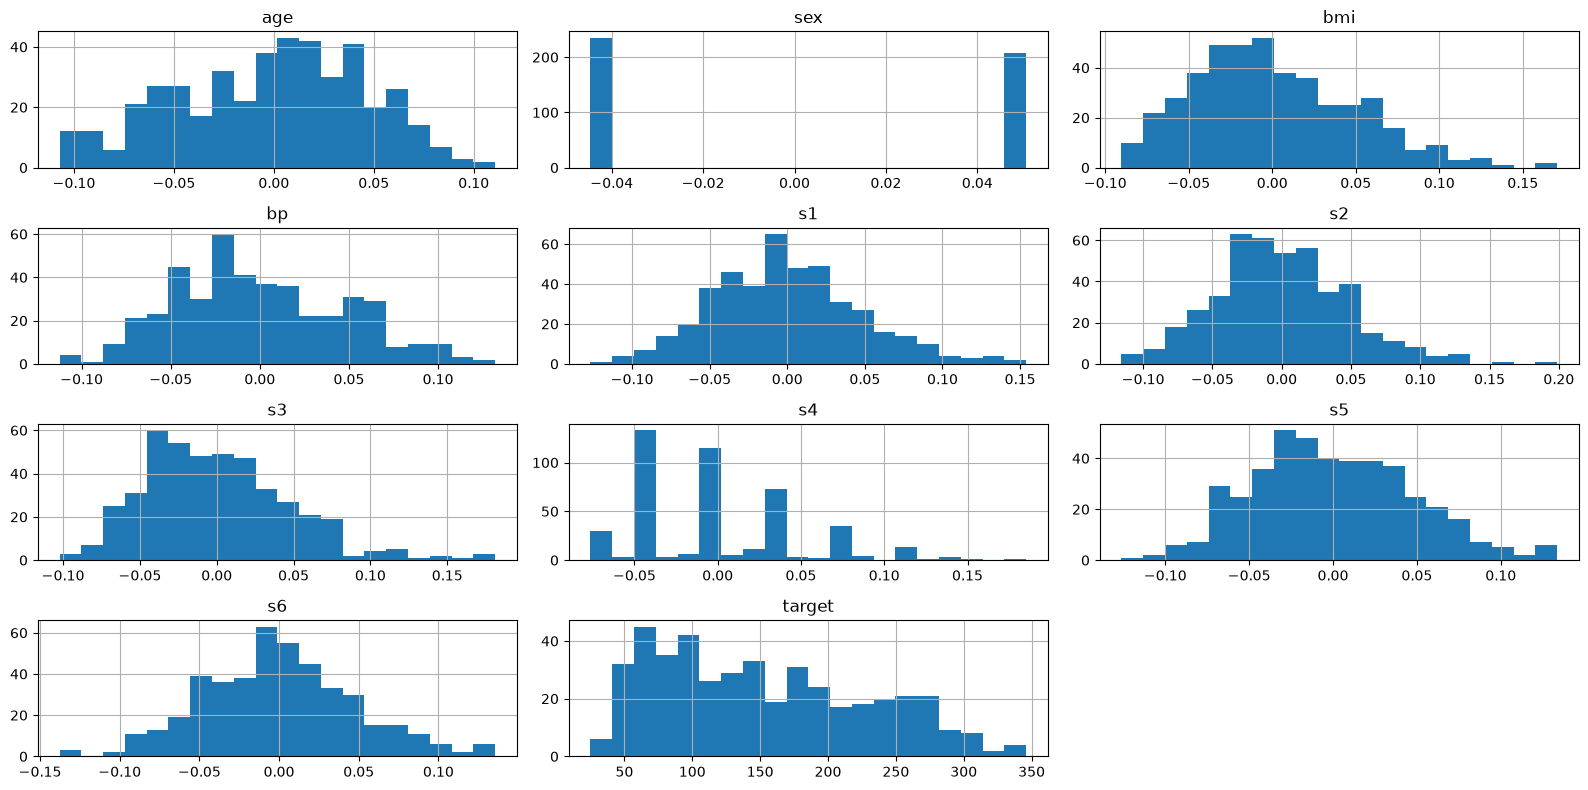

In [5]:
-

In [9]:
cors = df.corr(numeric_only=True)
print(cors['target'].sort_values(ascending=False))

target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64


In [10]:
df.head(5)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [13]:
print(df.skew(numeric_only=True))

age      -0.231382
sex       0.127385
bmi       0.598148
bp        0.290658
s1        0.378108
s2        0.436592
s3        0.799255
s4        0.735374
s5        0.291754
s6        0.207917
target    0.440563
dtype: float64


In [14]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

diab = load_diabetes()
X = diab.data[:, 2].reshape(-1, 1)   # BMI feature
y = diab.target                      # target

# Simple train-test split (no stratify, since y is continuous)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(353, 1) (89, 1) (353,) (89,)


In [18]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

y_train = scaler_Y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test = scaler_Y.transform(y_test.reshape(-1, 1)).ravel()

In [20]:
from sklearn.svm import SVR

svr =  SVR(kernel='linear', C=1000, gamma=0.5, epsilon=0.1)
svr.fit(X_train, y_train)

pred = svr.predict(X_test)
print(pred)

[-0.05697167 -0.02701783 -0.05547398 -0.01653398 -0.06670667 -0.06970206
  0.0658391  -0.02102706 -0.11538167 -0.04199475 -0.07569283 -0.09291629
 -0.09516283 -0.0427436  -0.0914186  -0.04873437 -0.00305475  0.00892679
 -0.0330086  -0.0120409  -0.02552014 -0.08243244 -0.08692552 -0.03675283
 -0.0217759  -0.0427436  -0.01129206 -0.06520898 -0.10414898 -0.06745552
  0.01192217 -0.07868821 -0.0427436  -0.05697167 -0.02477129  0.00143833
 -0.07419514 -0.07569283 -0.07419514 -0.09291629 -0.1011536  -0.07344629
 -0.06820437 -0.07569283 -0.08393014 -0.07719052 -0.07793937 -0.08767437
 -0.11163744 -0.05172975 -0.0120409  -0.1011536  -0.04049706 -0.08093475
 -0.06520898 -0.00754783 -0.08467898 -0.00979437 -0.06520898 -0.09066975
 -0.0315109  -0.02402244 -0.01503629 -0.08393014 -0.09815821 -0.03974821
 -0.0607159  -0.06970206 -0.07644167 -0.06146475 -0.06520898 -0.0315109
 -0.06745552 -0.05996706 -0.09516283 -0.0801859  -0.01054321 -0.02552014
 -0.03899937 -0.06670667 -0.05547398 -0.0607159  -0.

In [21]:
print(svr.score(X_test, y_test))

0.0329341033326529


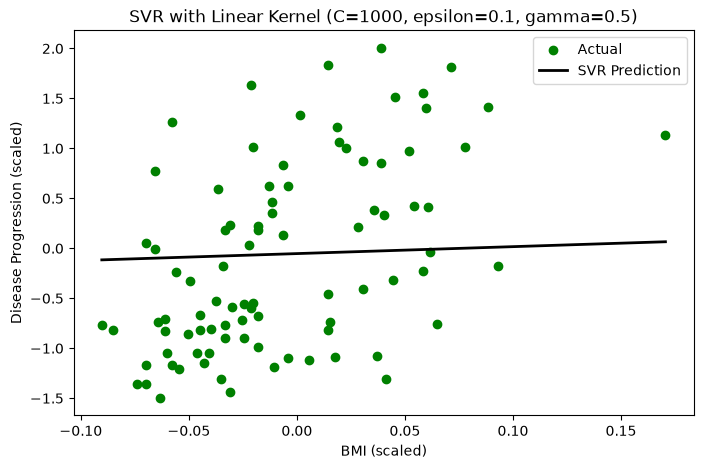

In [23]:
import numpy as np

# Sort test inputs by BMI feature (column 0 since X_test is 2D with one column)
sorted_idx = np.argsort(X_test[:, 0])

# Apply sorting to test data and predictions
X_test_sorted = X_test[sorted_idx]
y_test_sorted = y_test[sorted_idx]
y_pred_sorted = pred[sorted_idx]

# Now you can plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(X_test_sorted, y_test_sorted, color='green', label='Actual')
plt.plot(X_test_sorted, y_pred_sorted, color='black', linewidth=2, label='SVR Prediction')

plt.title("SVR with Linear Kernel (C=1000, epsilon=0.1, gamma=0.5)")
plt.xlabel("BMI (scaled)")
plt.ylabel("Disease Progression (scaled)")
plt.legend()
plt.show()


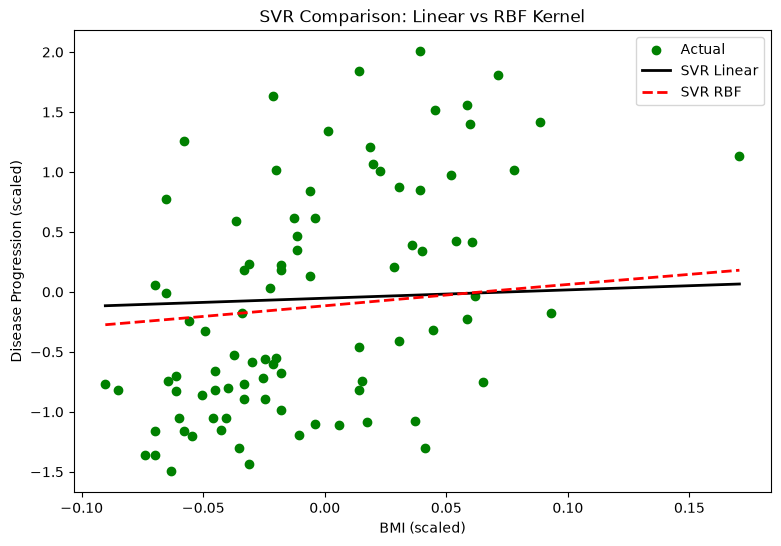

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR

# --- Linear SVR ---
svr_linear = SVR(kernel='linear', C=1000, epsilon=0.1)
svr_linear.fit(X_train, y_train)
y_pred_linear = svr_linear.predict(X_test)

# --- RBF SVR ---
svr_rbf = SVR(kernel='rbf', C=1000, gamma=0.5, epsilon=0.1)
svr_rbf.fit(X_train, y_train)
y_pred_rbf = svr_rbf.predict(X_test)

# --- Sorting by BMI feature ---
sorted_idx = np.argsort(X_test[:, 0])

X_test_sorted = X_test[sorted_idx]
y_test_sorted = y_test[sorted_idx]
y_pred_linear_sorted = y_pred_linear[sorted_idx]
y_pred_rbf_sorted = y_pred_rbf[sorted_idx]

# --- Plot ---
plt.figure(figsize=(9, 6))
plt.scatter(X_test_sorted, y_test_sorted, color='green', label='Actual')
plt.plot(X_test_sorted, y_pred_linear_sorted, color='black', linewidth=2, label='SVR Linear')
plt.plot(X_test_sorted, y_pred_rbf_sorted, color='red', linewidth=2, linestyle='--', label='SVR RBF')

plt.title("SVR Comparison: Linear vs RBF Kernel")
plt.xlabel("BMI (scaled)")
plt.ylabel("Disease Progression (scaled)")
plt.legend()
plt.show()


In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# --- Linear SVR evaluation ---
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
mae_linear = mean_absolute_error(y_test, y_pred_linear)

print("Linear SVR RMSE:", rmse_linear)
print("Linear SVR MAE:", mae_linear)

# --- RBF SVR evaluation ---
rmse_rbf = np.sqrt(mean_squared_error(y_test, y_pred_rbf))
mae_rbf = mean_absolute_error(y_test, y_pred_rbf)

print("RBF SVR RMSE:", rmse_rbf)
print("RBF SVR MAE:", mae_rbf)


Linear SVR RMSE: 0.9182630818865828
Linear SVR MAE: 0.8015369363710764
RBF SVR RMSE: 0.8936141854624782
RBF SVR MAE: 0.7738217864159073
